In [33]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [39]:
gVec = np.zeros((9, 360, 3))
sto110 = 1e4 * np.array([1, 1, 0]) / np.sqrt(2) * np.pi * 2 / 2.7613
sto220 = 1e4 * np.array([1, 1, 0]) / np.sqrt(2) * np.pi * 2 / 2.7613 * 2
sto330 = 1e4 * np.array([1, 1, 0]) / np.sqrt(2) * np.pi * 2 / 2.7613 * 3

sto212 = 1e4 * np.array([2, 1, 2]) / np.sqrt(9) * np.pi * 2 / 1.3017
sto223 = 1e4 * np.array([2, 2, 3]) / np.sqrt(17) * np.pi * 2 / 0.94710
sto313 = 1e4 * np.array([3, 1, 3]) / np.sqrt(19) * np.pi * 2 / 0.89587

sto111 = 1e4 * np.array([1, 1, 1]) / np.sqrt(3) * np.pi * 2 / 2.2546
sto222 = 1e4 * np.array([1, 1, 1]) / np.sqrt(3) * np.pi * 2 / 2.2546 * 2
sto333 = 1e4 * np.array([1, 1, 1]) / np.sqrt(3) * np.pi * 2 / 2.2546 * 3

g_list = [sto110, sto220, sto330, sto212, sto223, sto313, sto111, sto222, sto333, ]
labels = ['110', '220', '330', '212', '232', '313', '111', '222', '333']

tilt_angle = np.deg2rad(5)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])
for idx in range(360):
    angle = np.deg2rad(idx)
    rot_mat = np.array([[np.cos(angle), 0, -np.sin(angle)],
                        [0, 1, 0],
                        [np.sin(angle), 0, np.cos(angle)],
                        ])
    for gIdx in range(9):
        gVec[gIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, g_list[gIdx]))

In [40]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([np.cos(angle), 0, np.sin(angle)]) * kLen

tg_angle = np.deg2rad(0.7)
kvec_tg = np.copy(kvec)
kvec_tg[0] += 2 * np.sin(tg_angle) * kLen

In [41]:
kout = gVec + kvec_tg[np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

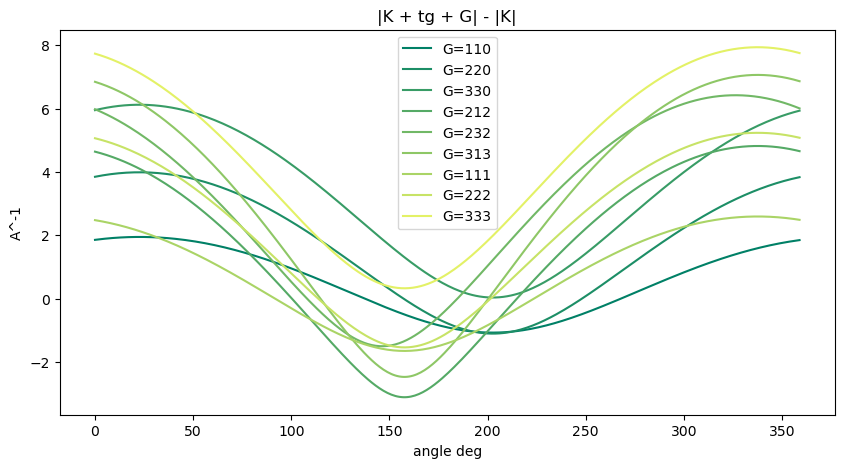

In [50]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for gIdx in range(9):
    ax.plot(np.arange(360), kout_len_diff[gIdx] / 1e4, label="G={}".format(labels[gIdx]), c=cmap(gIdx / 9))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
plt.legend()
plt.show()